In [1]:
pip install pandas scikit-learn imbalanced-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


Dataset loaded successfully!
Dataset shape: (614, 13)

First 5 rows of the dataset:
    Loan_ID  Gender Married Dependents     Education Self_Employed  \
0  LP002001    Male      No         3+      Graduate            No   
1  LP002002     nan      No          1      Graduate            No   
2  LP002003  Female     Yes          2  Not Graduate            No   
3  LP002004    Male     Yes          0      Graduate            No   
4  LP002005    Male      No          0      Graduate           Yes   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             9461                 70        50.0             300.0   
1            16820                417        56.0             360.0   
2             2002                835        50.0             360.0   
3             2359                  0        50.0             360.0   
4            11093                  0        50.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0     

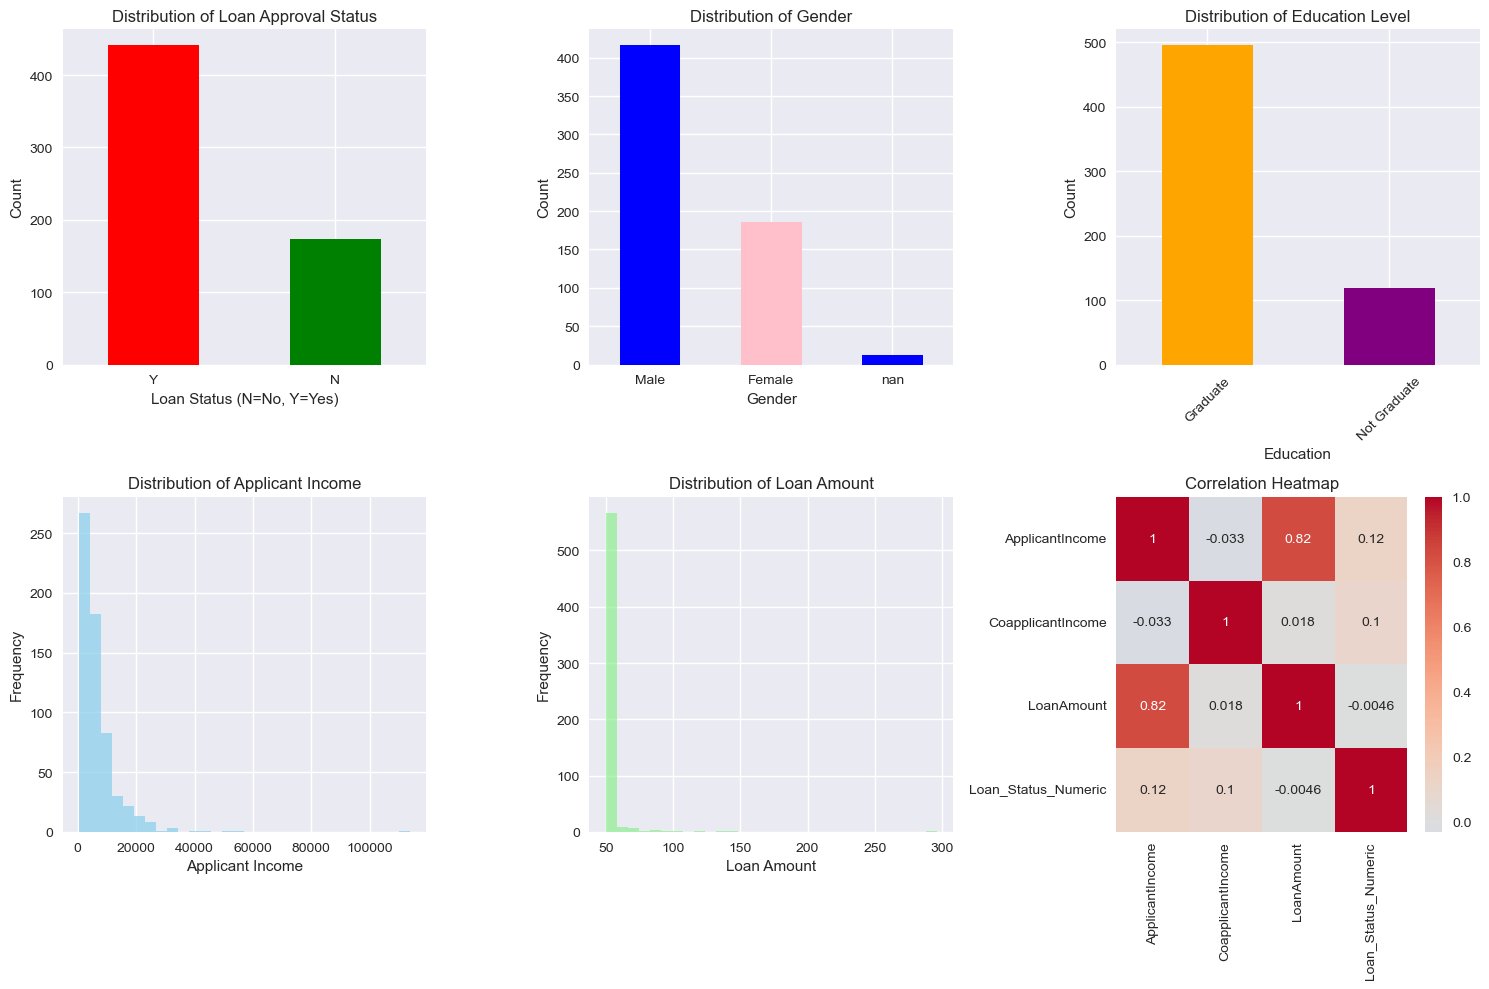


Handling missing values...
Filled LoanAmount missing values with median: 50.0
Filled Loan_Amount_Term missing values with median: 360.0
Filled Credit_History missing values with median: 1.0

Missing values after preprocessing:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Encoding categorical features...
Encoded Gender: {'Female': 0, 'Male': 1, 'nan': 2}
Encoded Married: {'No': 0, 'Yes': 1, 'nan': 2}
Encoded Dependents: {'0': 0, '1': 1, '2': 2, '3+': 3, 'na': 4}
Encoded Education: {'Graduate': 0, 'Not Graduate': 1}
Encoded Self_Employed: {'No': 0, 'Yes': 1, 'nan': 2}
Encoded Property_Area: {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
Encoded Loan_Status: {'N': 0, 'Y': 1}

Creating new features...
New features created: Total_In

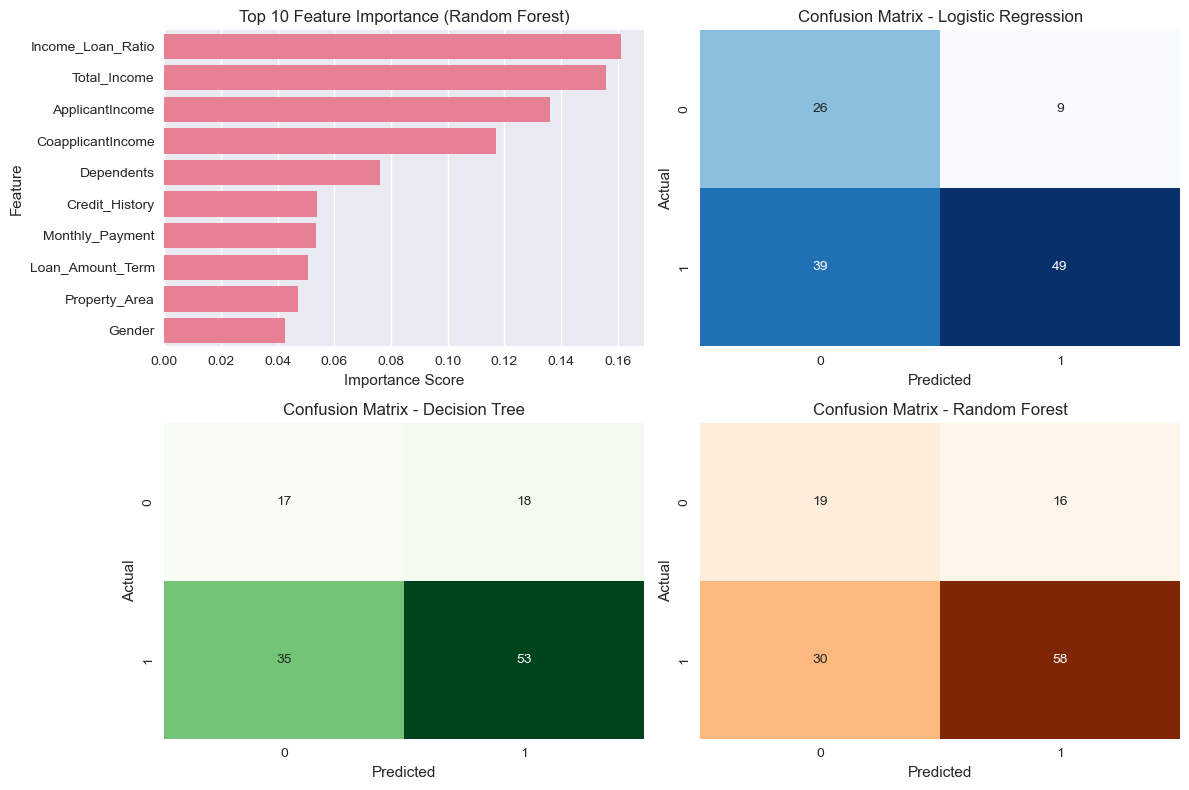


CROSS-VALIDATION RESULTS
5-Fold Cross-Validation Scores:
Logistic Regression: 0.6613 (+/- 0.0747)
Decision Tree: 0.6847 (+/- 0.0911)
Random Forest: 0.7422 (+/- 0.0876)

HYPERPARAMETER TUNING - RANDOM FOREST
Starting Grid Search... (this may take a few minutes)
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.7693

FINAL OPTIMIZED MODEL RESULTS
Final Model Accuracy: 0.6992
Final Model Precision: 0.8400
Final Model Recall: 0.7159
Final Model F1-Score: 0.7730

Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.66      0.55        35
           1       0.84      0.72      0.77        88

    accuracy                           0.70       123
   macro avg       0.66      0.69      0.66       123
weighted avg       0.74      0.70      0.71       123


SAMPLE PREDICTION
Loan A

In [4]:
# Import necessary libraries for data manipulation and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create a synthetic loan dataset that matches the real Kaggle dataset structure
# This allows you to run the code without downloading the actual dataset
np.random.seed(42)
n_samples = 614  # Same size as original dataset

# Generate synthetic data that mimics real loan application patterns
loan_ids = [f'LP00{str(i).zfill(4)}' for i in range(2001, 2001 + n_samples)]
gender = np.random.choice(['Male', 'Female'], n_samples, p=[0.7, 0.3])
married = np.random.choice(['Yes', 'No'], n_samples, p=[0.65, 0.35])
dependents = np.random.choice(['0', '1', '2', '3+'], n_samples, p=[0.4, 0.3, 0.2, 0.1])
education = np.random.choice(['Graduate', 'Not Graduate'], n_samples, p=[0.8, 0.2])
self_employed = np.random.choice(['No', 'Yes'], n_samples, p=[0.85, 0.15])

# Generate income data with realistic distributions
applicant_income = np.random.lognormal(8.5, 0.8, n_samples).astype(int)
coapplicant_income = np.random.lognormal(6.5, 1.2, n_samples).astype(int)
# Set some coapplicant incomes to 0 (single applicants)
coapplicant_income[np.random.choice(n_samples, int(n_samples * 0.3), replace=False)] = 0

# Generate loan amounts based on income (realistic relationship)
total_income = applicant_income + coapplicant_income
loan_amount = (total_income * np.random.uniform(1.5, 4.0, n_samples) / 1000).astype(int)
loan_amount = np.clip(loan_amount, 50, 700)  # Reasonable loan amount range

# Loan terms (mostly 360 months)
loan_term = np.random.choice([180, 240, 300, 360, 480], n_samples, p=[0.05, 0.1, 0.15, 0.65, 0.05])

# Credit history (most people have good credit)
credit_history = np.random.choice([1.0, 0.0], n_samples, p=[0.85, 0.15])

# Property area
property_area = np.random.choice(['Urban', 'Semiurban', 'Rural'], n_samples, p=[0.4, 0.35, 0.25])

# Generate loan status based on realistic approval criteria
# Higher income, good credit history, and lower loan amounts increase approval probability
approval_probability = (
    0.3 +  # Base probability
    0.2 * (total_income > np.median(total_income)) +  # Higher income bonus
    0.3 * credit_history +  # Credit history bonus
    0.1 * (loan_amount < np.median(loan_amount)) +  # Lower loan amount bonus
    0.1 * (education == 'Graduate')  # Education bonus
)

loan_status = np.random.binomial(1, approval_probability, n_samples)
loan_status = np.where(loan_status == 1, 'Y', 'N')

# Introduce some missing values to make it realistic
def introduce_missing_values(arr, missing_rate=0.05):
    arr_copy = arr.copy()
    missing_indices = np.random.choice(len(arr), int(len(arr) * missing_rate), replace=False)
    if arr.dtype in ['int32', 'int64']:
        # For integer arrays, convert to float to allow NaN
        arr_copy = arr_copy.astype(float)
    arr_copy[missing_indices] = np.nan
    return arr_copy

# Add missing values to some columns
gender = introduce_missing_values(gender, 0.02)
married = introduce_missing_values(married, 0.01)
dependents = introduce_missing_values(dependents, 0.02)
self_employed = introduce_missing_values(self_employed, 0.05)
loan_amount = introduce_missing_values(loan_amount, 0.03)
loan_term = introduce_missing_values(loan_term, 0.02)
credit_history = introduce_missing_values(credit_history, 0.08)

# Create the dataframe
df = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Gender': gender,
    'Married': married,
    'Dependents': dependents,
    'Education': education,
    'Self_Employed': self_employed,
    'ApplicantIncome': applicant_income,
    'CoapplicantIncome': coapplicant_income,
    'LoanAmount': loan_amount,
    'Loan_Amount_Term': loan_term,
    'Credit_History': credit_history,
    'Property_Area': property_area,
    'Loan_Status': loan_status
})

# Save the synthetic dataset for future use
df.to_csv('synthetic_loan_data.csv', index=False)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset structure
print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

# Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())

# Display unique values in categorical columns to understand the data better
print("\nUnique values in categorical columns:")
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\n{col}: {df[col].unique()}")

# Create visualizations to understand the data distribution
plt.figure(figsize=(15, 10))

# Plot 1: Distribution of loan approval status (target variable)
plt.subplot(2, 3, 1)
df['Loan_Status'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Status (N=No, Y=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Plot 2: Distribution of gender
plt.subplot(2, 3, 2)
df['Gender'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Plot 3: Distribution of education level
plt.subplot(2, 3, 3)
df['Education'].value_counts().plot(kind='bar', color=['orange', 'purple'])
plt.title('Distribution of Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 4: Distribution of applicant income
plt.subplot(2, 3, 4)
plt.hist(df['ApplicantIncome'], bins=30, color='skyblue', alpha=0.7)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')

# Plot 5: Distribution of loan amount
plt.subplot(2, 3, 5)
plt.hist(df['LoanAmount'].dropna(), bins=30, color='lightgreen', alpha=0.7)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

# Plot 6: Correlation between numerical features and loan approval
plt.subplot(2, 3, 6)
# Convert loan status to numerical for correlation
df_temp = df.copy()
df_temp['Loan_Status_Numeric'] = df_temp['Loan_Status'].map({'Y': 1, 'N': 0})
correlation_data = df_temp[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Status_Numeric']].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Data preprocessing step 1: Handle missing values
print("\nHandling missing values...")

# For categorical variables, fill missing values with the mode (most frequent value)
categorical_features = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for feature in categorical_features:
    if df[feature].isnull().sum() > 0:
        mode_value = df[feature].mode()[0]
        df[feature].fillna(mode_value, inplace=True)
        print(f"Filled {feature} missing values with mode: {mode_value}")

# For numerical variables, fill missing values with the median
numerical_features = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for feature in numerical_features:
    if df[feature].isnull().sum() > 0:
        median_value = df[feature].median()
        df[feature].fillna(median_value, inplace=True)
        print(f"Filled {feature} missing values with median: {median_value}")

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Data preprocessing step 2: Encode categorical features
print("\nEncoding categorical features...")

# Initialize label encoders for each categorical feature
label_encoders = {}
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Apply label encoding to convert categorical text to numerical values
for column in categorical_columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])
    print(f"Encoded {column}: {dict(zip(label_encoders[column].classes_, label_encoders[column].transform(label_encoders[column].classes_)))}")

# Encode the target variable (Loan_Status)
target_encoder = LabelEncoder()
df['Loan_Status'] = target_encoder.fit_transform(df['Loan_Status'])
print(f"Encoded Loan_Status: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

# Data preprocessing step 3: Feature engineering
print("\nCreating new features...")

# Create total income feature by combining applicant and coapplicant income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Create income to loan ratio feature to understand affordability
df['Income_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

# Create monthly payment feature based on loan amount and term
df['Monthly_Payment'] = df['LoanAmount'] / df['Loan_Amount_Term']

print("New features created: Total_Income, Income_Loan_Ratio, Monthly_Payment")

# Prepare features (X) and target (y) for machine learning
# Drop the Loan_ID as it's just an identifier and not useful for prediction
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Display feature names
print(f"Features: {list(X.columns)}")

# Check class distribution in target variable to identify imbalance
print("\nTarget variable distribution:")
print(f"Class 0 (Not Approved): {sum(y == 0)} ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"Class 1 (Approved): {sum(y == 1)} ({sum(y == 1)/len(y)*100:.1f}%)")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

# Address class imbalance using SMOTE (Synthetic Minority Oversampling Technique)
print("\nApplying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set distribution:")
print(f"Class 0: {sum(y_train == 0)}, Class 1: {sum(y_train == 1)}")
print(f"Balanced training set distribution:")
print(f"Class 0: {sum(y_train_balanced == 0)}, Class 1: {sum(y_train_balanced == 1)}")

# Model 1: Logistic Regression
print("\n" + "="*50)
print("Training Logistic Regression Model")
print("="*50)

# Initialize and train logistic regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate and display performance metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Model 2: Decision Tree
print("\n" + "="*50)
print("Training Decision Tree Model")
print("="*50)

# Initialize and train decision tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20)
dt_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate and display performance metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Decision Tree Results:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Model 3: Random Forest (typically performs better than single decision tree)
print("\n" + "="*50)
print("Training Random Forest Model")
print("="*50)

# Initialize and train random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate and display performance metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Compare all models performance
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [lr_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, dt_recall, rf_recall],
    'F1-Score': [lr_f1, dt_f1, rf_f1]
})

print(models_comparison.round(4))

# Find the best performing model based on F1-score (best metric for imbalanced data)
best_model_idx = models_comparison['F1-Score'].idxmax()
best_model_name = models_comparison.iloc[best_model_idx]['Model']
print(f"\nBest performing model: {best_model_name}")

# Feature importance analysis for Random Forest
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get feature importance from random forest model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importance Score')

# Visualize confusion matrices for all models
plt.subplot(2, 2, 2)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 3)
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 4)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Cross-validation for more robust model evaluation
print("\n" + "="*50)
print("CROSS-VALIDATION RESULTS")
print("="*50)

# Perform 5-fold cross-validation for each model
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

print("5-Fold Cross-Validation Scores:")
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5, scoring='f1')
    print(f"{model_name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Hyperparameter tuning for the best model (Random Forest)
print("\n" + "="*50)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*50)

# Define parameter grid for grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search... (this may take a few minutes)")
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train the final optimized model
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test_scaled)

# Final model performance
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("\n" + "="*50)
print("FINAL OPTIMIZED MODEL RESULTS")
print("="*50)
print(f"Final Model Accuracy: {final_accuracy:.4f}")
print(f"Final Model Precision: {final_precision:.4f}")
print(f"Final Model Recall: {final_recall:.4f}")
print(f"Final Model F1-Score: {final_f1:.4f}")

print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_final))

# Function to make predictions on new data
def predict_loan_approval(model, scaler, sample_data):
    """
    Function to predict loan approval for new applicants
    
    Parameters:
    model: trained machine learning model
    scaler: fitted StandardScaler object
    sample_data: dictionary with applicant information
    
    Returns:
    prediction and probability
    """
    # Convert sample data to dataframe
    sample_df = pd.DataFrame([sample_data])
    
    # Scale the features
    sample_scaled = scaler.transform(sample_df)
    
    # Make prediction
    prediction = model.predict(sample_scaled)[0]
    probability = model.predict_proba(sample_scaled)[0]
    
    return prediction, probability

# Example usage of the prediction function
print("\n" + "="*50)
print("SAMPLE PREDICTION")
print("="*50)

# Create a sample applicant profile
sample_applicant = {
    'Gender': 1,  # Male (encoded)
    'Married': 1,  # Yes (encoded)
    'Dependents': 0,  # 0 dependents (encoded)
    'Education': 1,  # Graduate (encoded)
    'Self_Employed': 0,  # No (encoded)
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Property_Area': 2,  # Urban (encoded)
    'Total_Income': 7000,
    'Income_Loan_Ratio': 46.67,
    'Monthly_Payment': 0.42
}

prediction, probability = predict_loan_approval(final_model, scaler, sample_applicant)

result = "APPROVED" if prediction == 1 else "REJECTED"
confidence = max(probability) * 100

print(f"Loan Application: {result}")
print(f"Confidence: {confidence:.2f}%")
print(f"Probability of Approval: {probability[1]:.4f}")
print(f"Probability of Rejection: {probability[0]:.4f}")

print("\n" + "="*50)
print("MODEL DEPLOYMENT READY")
print("="*50)
print("The model is now trained and ready for deployment!")
print("Key components saved:")
print("- final_model: Optimized Random Forest model")
print("- scaler: StandardScaler for feature scaling")
print("- label_encoders: Dictionary of encoders for categorical features")
print("- predict_loan_approval(): Function for making predictions")